# Test: Python Wrapper for QG Drifter Simulation

This notebook tests the Python wrapper (`py/qg_drifters.py`) that drives the Julia drifter simulation via subprocess.

In [1]:
import sys
sys.path.insert(0, 'py')
from qg_drifters import run_drifters, load_trajectories

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import os

## Step 1: Run the drifter simulation

Deploy 256 drifters (16x16 grid) and advect for 30 days starting from day 5000.

In [2]:
traj, meta = run_drifters(t_start=5001, n_days=30, n_per_side=16, cache=True)

print(f"DataFrame shape: {traj.shape}")
print(f"Metadata: {meta}")
print(f"\nUnique drifters: {traj.ID.nunique()}")
print(f"Time range: {traj.t.min()/86400:.0f} to {traj.t.max()/86400:.0f} days")
traj.head()

Using cached results: /tmp/qg_drifters/traj_t5001_d30_n16_l1_r1.csv
DataFrame shape: (7936, 6)
Metadata: {'dx': 3906.25, 'nx': 256, 'n_drifters': 256, 't_start': 5001, 'n_days': 30, 'n_per_side': 16, 'lev': 1}

Unique drifters: 256
Time range: 0 to 30 days


,ID,x,y,t,x_m,y_m
0,1.0,8.0,8.0,0.0,31250.0,31250.0
1,2.0,24.0,8.0,0.0,93750.0,31250.0
2,3.0,40.0,8.0,0.0,156250.0,31250.0
3,4.0,56.0,8.0,0.0,218750.0,31250.0
4,5.0,72.0,8.0,0.0,281250.0,31250.0


## Step 2: Load QG velocity field for background plots

In [3]:
qg = xr.open_dataset(os.path.join(os.environ['OS_DATA'], 'QG', 'QGModelOutput20years.nc'))
u0 = qg.u.isel(lev=0, time=5000).values
v0 = qg.v.isel(lev=0, time=5000).values
speed = np.sqrt(u0**2 + v0**2)
x_km = qg.x.values / 1000
y_km = qg.y.values / 1000
qg.close()

dx = meta['dx']
nx = meta['nx']
L = nx * dx  # domain size in meters

## Figure 1: Drifter trajectories over speed field

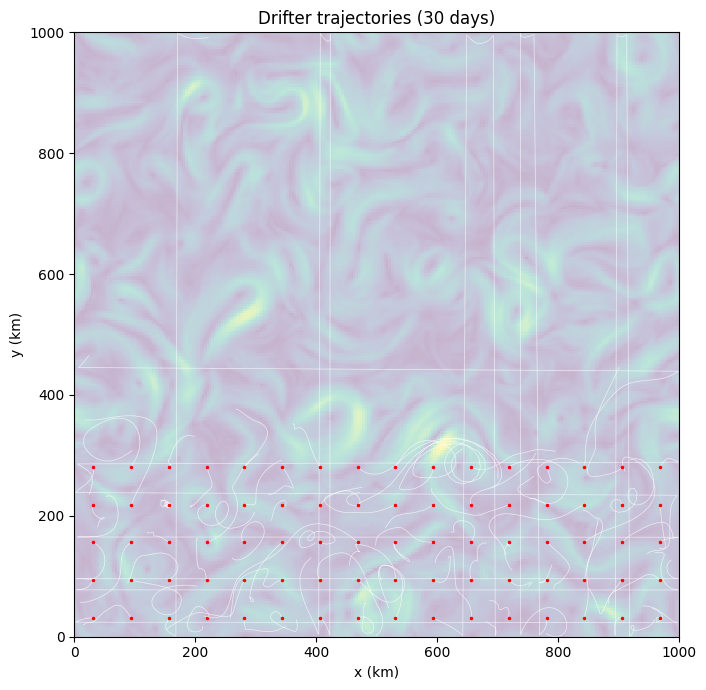

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(8, 7))
ax.pcolormesh(x_km, y_km, speed.T, cmap='viridis', alpha=0.3, shading='auto')
for did in range(1, min(81, int(traj.ID.max()) + 1)):
    sub = traj[traj.ID == did]
    ax.plot(sub.x_m / 1000, sub.y_m / 1000, 'w-', lw=0.5, alpha=0.7)
    ax.plot(sub.x_m.iloc[0] / 1000, sub.y_m.iloc[0] / 1000, 'r.', ms=3)
ax.set_xlabel('x (km)')
ax.set_ylabel('y (km)')
ax.set_title('Drifter trajectories (30 days)')
ax.set_aspect('equal')
plt.tight_layout()

## Figure 2: Mean displacement from origin

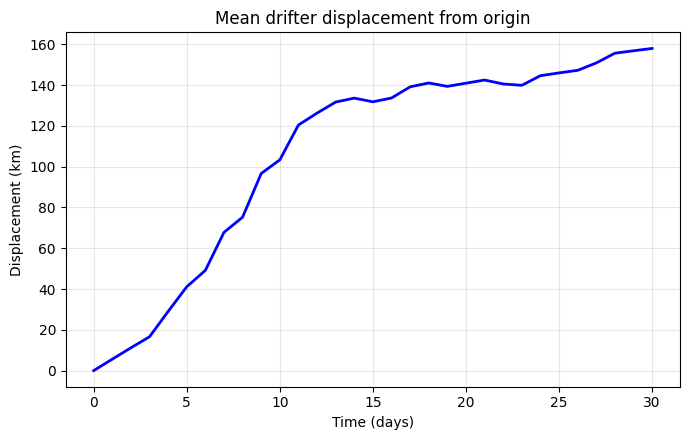

In [5]:
init = traj[traj.t == 0.0].reset_index(drop=True)
times = np.sort(traj.t.unique())
times_days = times / 86400

mean_disp = []
for t_val in times:
    sub = traj[traj.t == t_val].reset_index(drop=True)
    d = np.sqrt((sub.x_m.values - init.x_m.values)**2 + (sub.y_m.values - init.y_m.values)**2)
    mean_disp.append(np.mean(d))
mean_disp = np.array(mean_disp)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(times_days, mean_disp / 1000, 'b-', lw=2)
ax.set_xlabel('Time (days)')
ax.set_ylabel('Displacement (km)')
ax.set_title('Mean drifter displacement from origin')
ax.grid(True, alpha=0.3)
plt.tight_layout()

## Figure 3: Pair separation for initially-close pairs

Select pairs that start within 100 km of each other and track their separation over time.

Found 300 close pairs (r0 < 100 km)


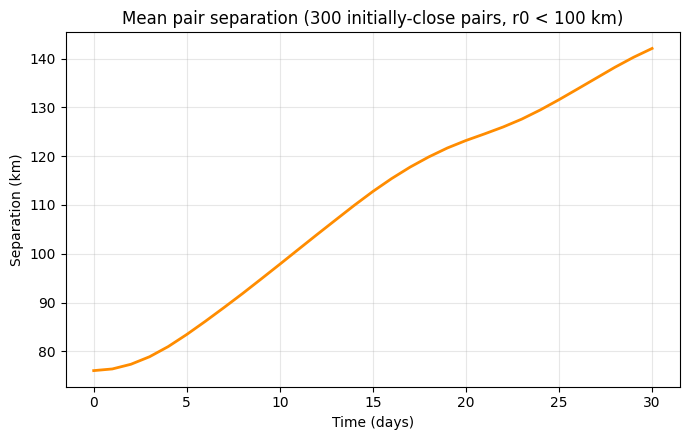

In [6]:
n = int(traj.ID.max())
close_pairs = []
for i in range(1, n + 1):
    for j in range(i + 1, n + 1):
        xi = init[init.ID == i].x_m.values[0]
        yi = init[init.ID == i].y_m.values[0]
        xj = init[init.ID == j].x_m.values[0]
        yj = init[init.ID == j].y_m.values[0]
        ddx = xi - xj; ddx -= L * round(ddx / L)
        ddy = yi - yj; ddy -= L * round(ddy / L)
        r0 = np.sqrt(ddx**2 + ddy**2)
        if r0 < 100e3:
            close_pairs.append((i, j, r0))
        if len(close_pairs) >= 300:
            break
    if len(close_pairs) >= 300:
        break

print(f"Found {len(close_pairs)} close pairs (r0 < 100 km)")

mean_sep = []
for t_val in times:
    sub = traj[traj.t == t_val].set_index('ID')
    seps = []
    for (i, j, _) in close_pairs:
        ddx = sub.loc[i, 'x_m'] - sub.loc[j, 'x_m']
        ddy = sub.loc[i, 'y_m'] - sub.loc[j, 'y_m']
        ddx -= L * round(ddx / L)
        ddy -= L * round(ddy / L)
        seps.append(np.sqrt(ddx**2 + ddy**2))
    mean_sep.append(np.mean(seps))
mean_sep = np.array(mean_sep)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(times_days, mean_sep / 1000, '-', lw=2, color='darkorange')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Separation (km)')
ax.set_title(f'Mean pair separation ({len(close_pairs)} initially-close pairs, r0 < 100 km)')
ax.grid(True, alpha=0.3)
plt.tight_layout()

## Figure 4: Drifter snapshots at days 0, 10, 30

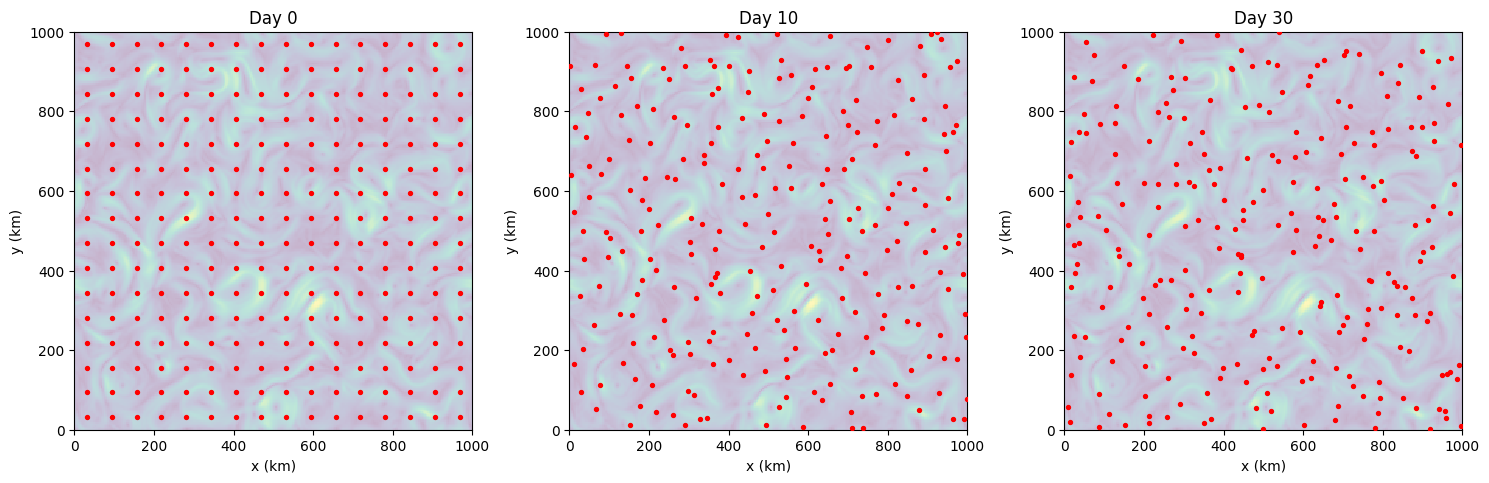

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, day in zip(axes, [0, 10, 30]):
    t_val = day * 86400.0
    sub = traj[traj.t == t_val]
    ax.pcolormesh(x_km, y_km, speed.T, cmap='viridis', alpha=0.3, shading='auto')
    ax.scatter(sub.x_m / 1000, sub.y_m / 1000, s=8, c='red', zorder=5)
    ax.set_xlabel('x (km)')
    ax.set_ylabel('y (km)')
    ax.set_title(f'Day {day}')
    ax.set_aspect('equal')
plt.tight_layout()

## Figure 5: Displacement histogram at day 30

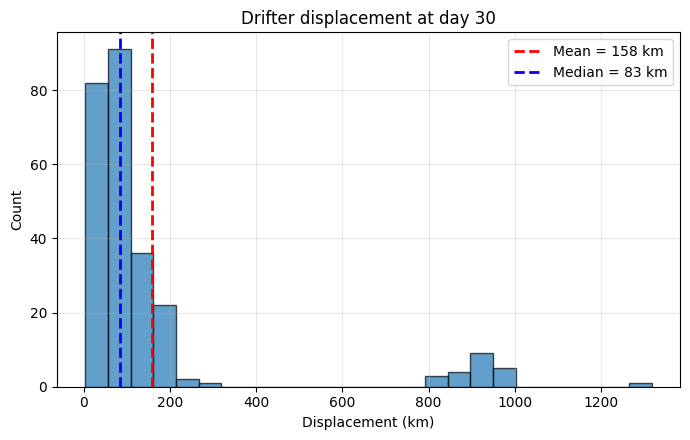

In [8]:
final = traj[traj.t == traj.t.max()].reset_index(drop=True)
disp = np.sqrt((final.x_m.values - init.x_m.values)**2 + (final.y_m.values - init.y_m.values)**2) / 1000

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(disp, bins=25, edgecolor='black', alpha=0.7)
ax.axvline(np.mean(disp), color='red', ls='--', lw=2, label=f'Mean = {np.mean(disp):.0f} km')
ax.axvline(np.median(disp), color='blue', ls='--', lw=2, label=f'Median = {np.median(disp):.0f} km')
ax.set_xlabel('Displacement (km)')
ax.set_ylabel('Count')
ax.set_title('Drifter displacement at day 30')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

## Test: Caching

Running with `cache=True` should skip Julia entirely if the output already exists.

In [9]:
%%time
traj2, meta2 = run_drifters(t_start=5001, n_days=30, n_per_side=16, cache=True)
print(f"Cached result: {traj2.shape[0]} rows")

Using cached results: /tmp/qg_drifters/traj_t5001_d30_n16_l1_r1.csv
Cached result: 7936 rows
CPU times: user 8.95 ms, sys: 3.03 ms, total: 12 ms
Wall time: 11.1 ms
